<a href="https://colab.research.google.com/github/souarenar/prediction-churn-bancaire/blob/main/churn_bancaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Supprimer les colonnes inutiles
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Transformer les colonnes texte en variables numériques
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

print(df.shape)
df.head()

(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = toutes les colonnes sauf la cible, y = la cible (Exited)
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisation (nécessaire pour la régression logistique et le SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Entraînement :", X_train.shape, " Test :", X_test.shape)

Entraînement : (8000, 11)  Test : (2000, 11)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}

# 1. Régression logistique
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
results["Régression logistique"] = accuracy_score(y_test, y_pred_log)

# 2. Arbre de décision
tree = DecisionTreeClassifier(random_state=42, max_depth=6)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
results["Arbre de décision"] = accuracy_score(y_test, y_pred_tree)

# 3. SVM
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
results["SVM"] = accuracy_score(y_test, y_pred_svm)

for nom, acc in results.items():
    print(f"{nom} : {acc:.3f}")

Régression logistique : 0.808
Arbre de décision : 0.861
SVM : 0.861


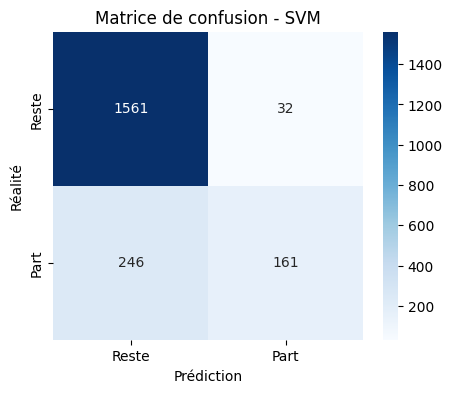

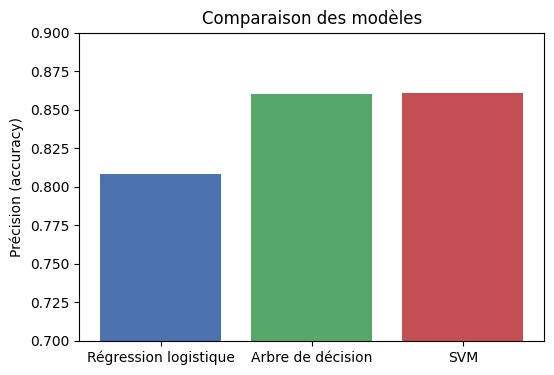

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matrice de confusion du SVM (meilleur modèle)
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Reste", "Part"], yticklabels=["Reste", "Part"])
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - SVM")
plt.show()

# Comparaison des 3 modèles
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Précision (accuracy)")
plt.title("Comparaison des modèles")
plt.ylim(0.7, 0.9)
plt.show()